## Notation
Here is a summary of some of the notation you will encounter.  

|General <img width=70/> <br />  Notation  <img width=70/> | Description<img width=350/>| Python (if applicable) |
|:------------|:------------------------------------------------------------|:------------|
| $a$ | scalar, non bold | |
| $\mathbf{a}$ | vector, bold | |
| **Regression** | | |
|  $\mathbf{x}$ | Training Example feature values (in this lab - Size (1000 sqft))  | `x_train` |
|  $\mathbf{y}$  | Training Example  targets (in this lab Price (1000s of dollars))  | `y_train` |
|  $x^{(i)}$, $y^{(i)}$ | $i_{th}$Training Example | `x_i`, `y_i`|
| m | Number of training examples | `m`|
|  $w$  |  parameter: weight                                 | `w`    |
|  $b$           |  parameter: bias                                           | `b`    |
| $f_{w,b}(x^{(i)})$ | The result of the model evaluation at $x^{(i)}$ parameterized by $w,b$: $f_{w,b}(x^{(i)}) = wx^{(i)}+b$  | `f_wb` |


In [74]:
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use('/Users/cheerupdimbo/Documents/ds-sprint-july/ds-sprint-july/week3_ml_core/deeplearning.mplstyle')

In [75]:
# x_train is the input variable
x_train = np.array([1.0, 2.0])

# y_train is the target
y_train = np.array([300.0, 500.0])

In [76]:
# m is the number of training example
## using .shape
m = x_train.shape[0]
## using len()
m = len(x_train)
print(f"Number of training examples is {m}")

Number of training examples is 2


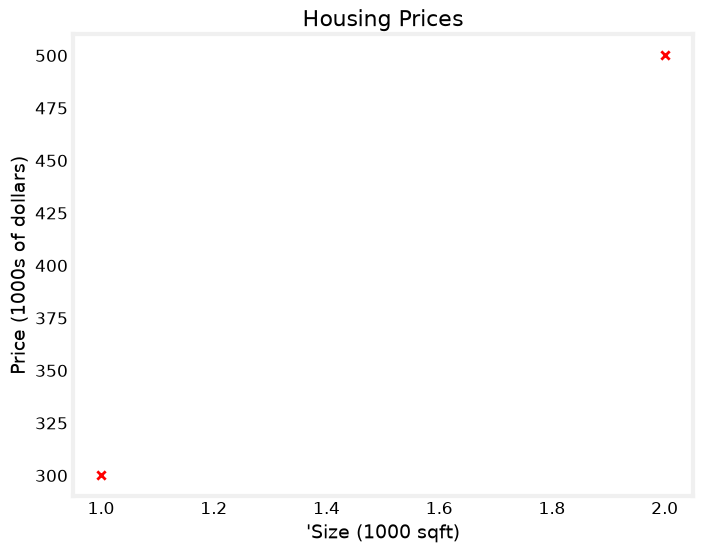

In [77]:
# scatter plot where x_train is the input variable and y_train is the target, 
# marker is 'x' and color is red
plt.scatter(x_train, y_train, marker='x', c='r')

plt.title("Housing Prices")
plt.xlabel("'Size (1000 sqft)")
plt.ylabel("Price (1000s of dollars)")
plt.show()

In [78]:
w = 100
b = 100

def compute_model_output(x,w,b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

temp_f_wb = compute_model_output(x_train, w, b)

f_wb: [200. 300.]


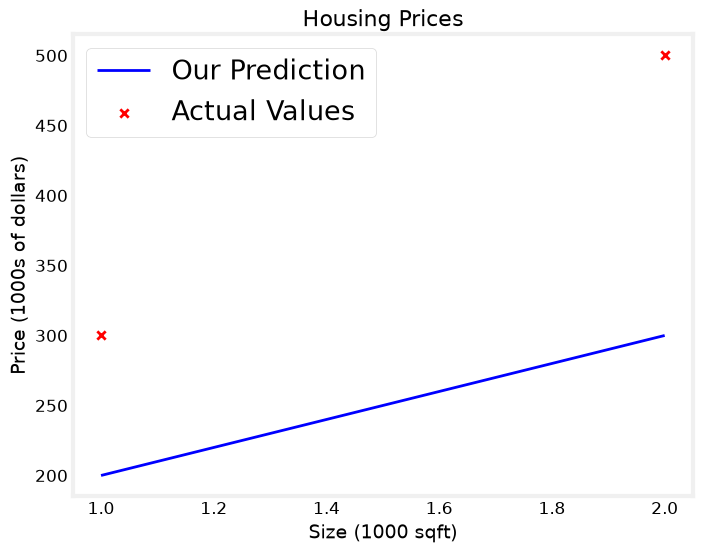

In [79]:
plt.plot(x_train, temp_f_wb, c='b', label = 'Our Prediction')
print(f"f_wb: {temp_f_wb}")

plt.scatter(x_train, y_train, marker='x', c='r', label = 'Actual Values')
plt.title("Housing Prices")
plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (1000s of dollars)")
plt.legend()
plt.show()

In linear regression, you utilize input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $f_{w,b}(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$, $J(w,b)$. In training you measure the cost over all of our training samples $x^{(i)},y^{(i)}$
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$ (2)

In [80]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb_i = w * x[i] + b
        cost += (f_wb_i - y[i]) ** 2
    total_cost = cost / (2 * m)
    return total_cost

In [81]:
import math, copy

The gradient is defined as:
$$
\begin{align*}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \\
\frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})
\end{align*}
$$ (4)(5)

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

## Implement Gradient Descent
You will implement gradient descent algorithm for one feature. You will need three functions. 
- `compute_gradient` implementing equation (4) and (5) above
- `compute_cost` implementing equation (2) above (code from previous lab)
- `gradient_descent`, utilizing compute_gradient and compute_cost

In [ ]:
def compute_gradient(x,y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w* x[i] + b
        dj_dw_i = (f_wb - y[i] * x[i])
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i 
        dj_dw += dj_dw_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db
